# Test Stereo Rectification with SIFT Calibration

This notebook demonstrates how to use the SIFT-based stereo calibration parameters to rectify stereo image pairs.

In [21]:
import numpy as np
import cv2
import pickle
import matplotlib.pyplot as plt
import glob

In [22]:
# Load the SIFT-based calibration data
with open('stereo_rectification_params.pkl', 'rb') as f:
    calibration_data = pickle.load(f)

print("Calibration data loaded successfully")
print("\nAvailable keys:", list(calibration_data.keys()))

Calibration data loaded successfully

Available keys: ['H1', 'H2', 'F', 'left_camera_matrix', 'left_dist_coeffs', 'left_new_camera_matrix', 'right_camera_matrix', 'right_dist_coeffs', 'right_new_camera_matrix']


In [23]:
# Extract calibration parameters
H1 = calibration_data['H1']
H2 = calibration_data['H2']
F = calibration_data['F']

mtx_left = calibration_data['left_camera_matrix']
dist_left = calibration_data['left_dist_coeffs']
newcameramtx_left = calibration_data['left_new_camera_matrix']

mtx_right = calibration_data['right_camera_matrix']
dist_right = calibration_data['right_dist_coeffs']
newcameramtx_right = calibration_data['right_new_camera_matrix']

print("Calibration parameters extracted")
print(f"Left camera matrix shape: {mtx_left.shape}")
print(f"Right camera matrix shape: {mtx_right.shape}")
print(f"Homography H1 shape: {H1.shape}")
print(f"Homography H2 shape: {H2.shape}")

Calibration parameters extracted
Left camera matrix shape: (3, 3)
Right camera matrix shape: (3, 3)
Homography H1 shape: (3, 3)
Homography H2 shape: (3, 3)


In [24]:
# Load a stereo pair (you can change the image paths)
left_images = sorted(glob.glob(r"34759_final_project_raw\34759_final_project_raw\seq_01\image_02\data\*.png"))
right_images = sorted(glob.glob(r"34759_final_project_raw\34759_final_project_raw\seq_01\image_03\data\*.png"))

# Select an image (change index to test different images)
img_index = 0

img_left_raw = cv2.imread(left_images[img_index])
img_right_raw = cv2.imread(right_images[img_index])

#print(f"Loaded image pair: {left_images[img_index].split('\\')[-1]}")
#print(f"Image size: {img_left_raw.shape[:2]}")

In [25]:
# Apply rectification using the calibration maps
# First undistort the images
img_left_undist = cv2.undistort(img_left_raw, mtx_left, dist_left, None, newcameramtx_left)
img_right_undist = cv2.undistort(img_right_raw, mtx_right, dist_right, None, newcameramtx_right)

# Then apply rectification using homography matrices
h, w = img_left_undist.shape[:2]
img_left_rectified = cv2.warpPerspective(img_left_undist, H1, (w, h))
img_right_rectified = cv2.warpPerspective(img_right_undist, H2, (w, h))

print("Undistortion and rectification applied successfully")

Undistortion and rectification applied successfully


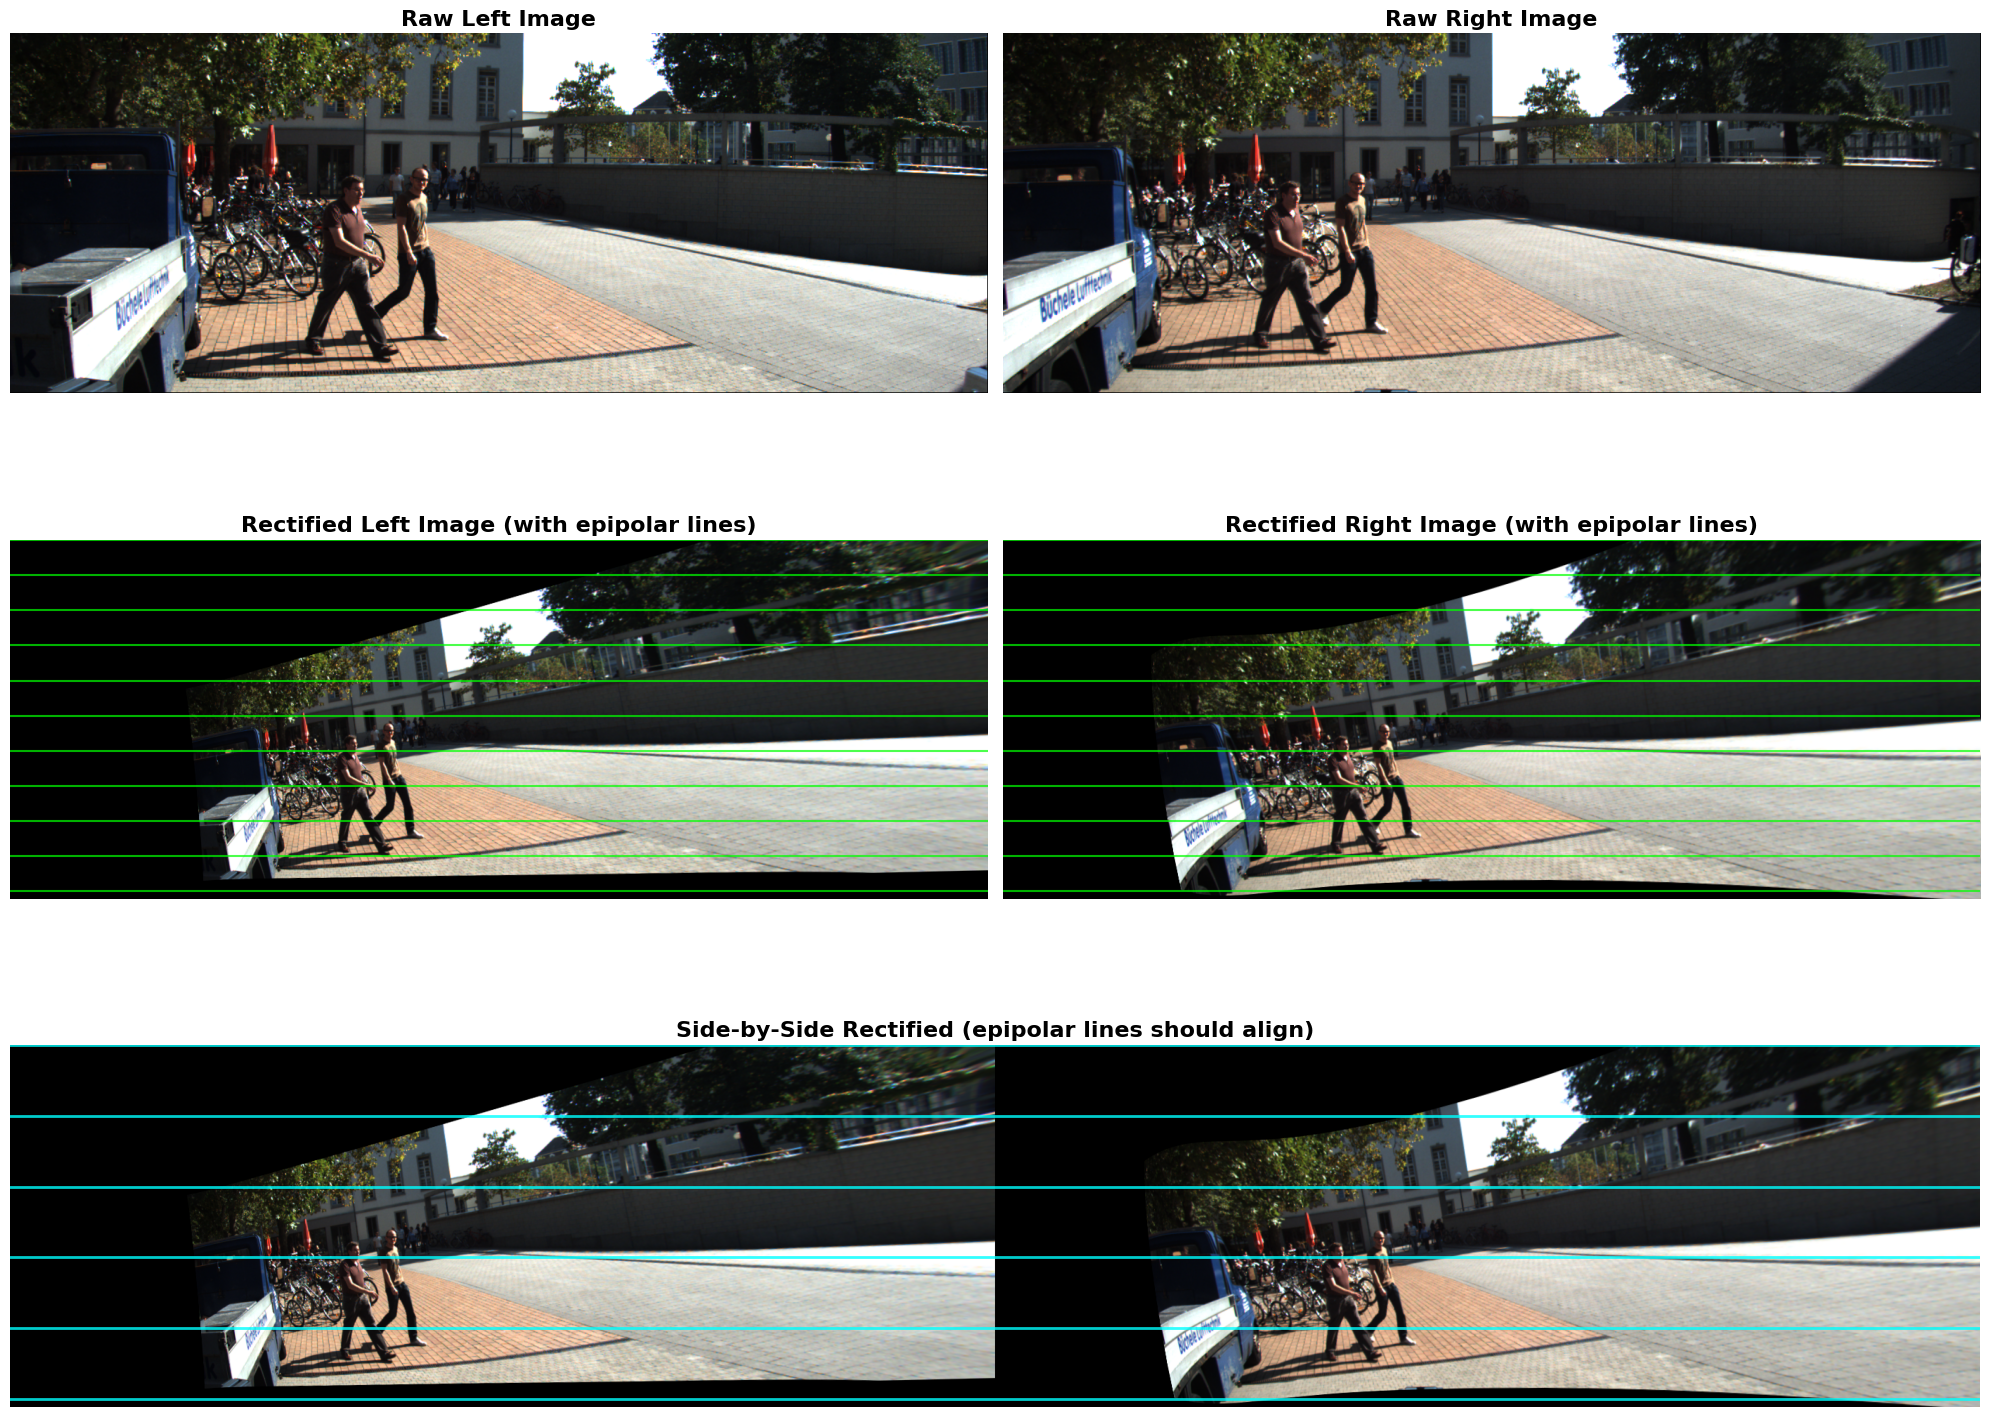

In [26]:
# Visualize raw and rectified stereo pairs
fig = plt.figure(figsize=(20, 16))

# Raw left image
ax1 = plt.subplot(3, 2, 1)
ax1.imshow(cv2.cvtColor(img_left_raw, cv2.COLOR_BGR2RGB))
ax1.set_title('Raw Left Image', fontsize=16, fontweight='bold')
ax1.axis('off')

# Raw right image
ax2 = plt.subplot(3, 2, 2)
ax2.imshow(cv2.cvtColor(img_right_raw, cv2.COLOR_BGR2RGB))
ax2.set_title('Raw Right Image', fontsize=16, fontweight='bold')
ax2.axis('off')

# Rectified left image with epipolar lines
ax3 = plt.subplot(3, 2, 3)
ax3.imshow(cv2.cvtColor(img_left_rectified, cv2.COLOR_BGR2RGB))
for y in range(0, img_left_rectified.shape[0], 50):
    ax3.axhline(y=y, color='lime', linewidth=1.5, alpha=0.7)
ax3.set_title('Rectified Left Image (with epipolar lines)', fontsize=16, fontweight='bold')
ax3.axis('off')

# Rectified right image with epipolar lines
ax4 = plt.subplot(3, 2, 4)
ax4.imshow(cv2.cvtColor(img_right_rectified, cv2.COLOR_BGR2RGB))
for y in range(0, img_right_rectified.shape[0], 50):
    ax4.axhline(y=y, color='lime', linewidth=1.5, alpha=0.7)
ax4.set_title('Rectified Right Image (with epipolar lines)', fontsize=16, fontweight='bold')
ax4.axis('off')

# Side-by-side comparison (rectified)
combined_rect = np.hstack((img_left_rectified, img_right_rectified))
ax5 = plt.subplot(3, 1, 3)
ax5.imshow(cv2.cvtColor(combined_rect, cv2.COLOR_BGR2RGB))
for y in range(0, combined_rect.shape[0], 100):
    ax5.axhline(y=y, color='cyan', linewidth=2, alpha=0.8)
ax5.set_title('Side-by-Side Rectified (epipolar lines should align)', fontsize=16, fontweight='bold')
ax5.axis('off')

plt.tight_layout()
plt.show()

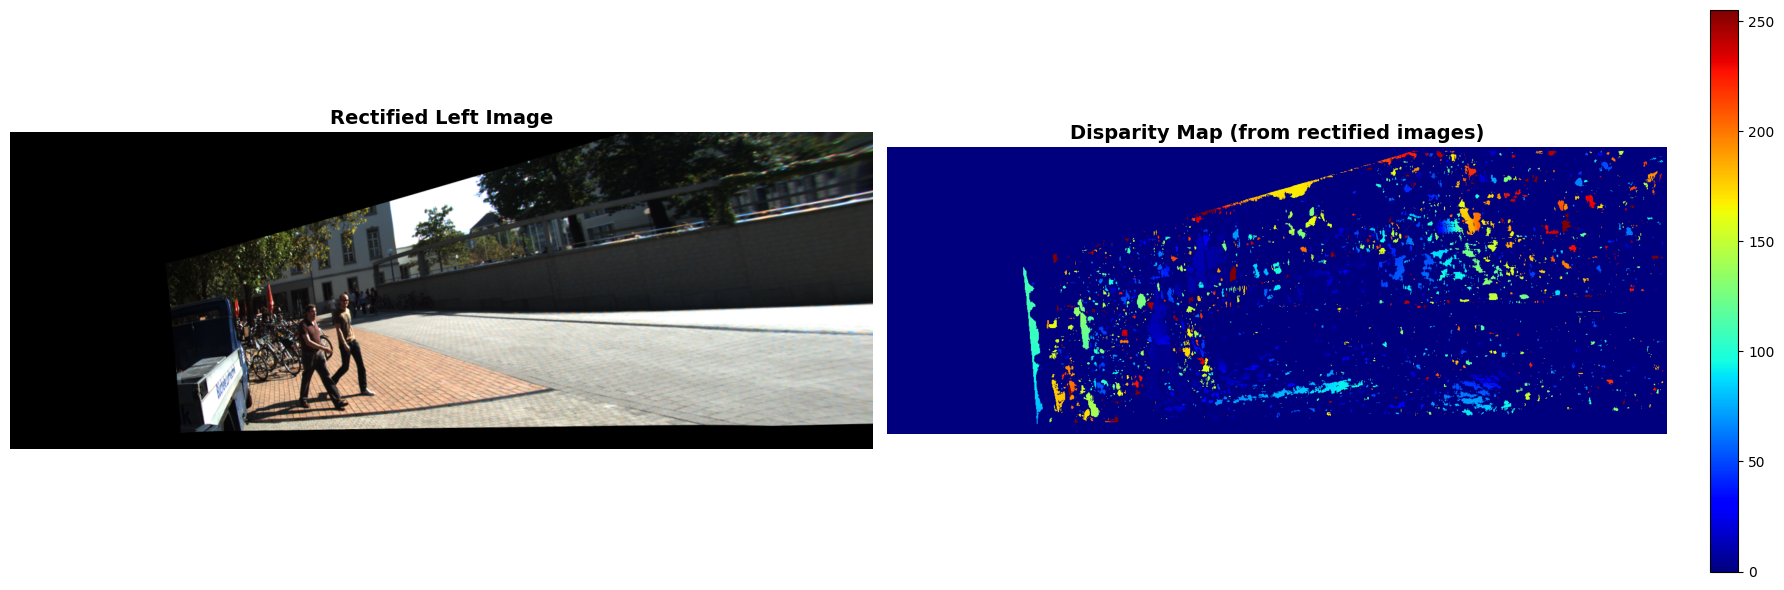

In [27]:
# Compute and visualize disparity map using the rectified images
stereo_matcher = cv2.StereoBM_create(numDisparities=16*6, blockSize=15)

gray_left = cv2.cvtColor(img_left_rectified, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right_rectified, cv2.COLOR_BGR2GRAY)

disparity = stereo_matcher.compute(gray_left, gray_right)
disparity_normalized = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(img_left_rectified, cv2.COLOR_BGR2RGB))
axes[0].set_title('Rectified Left Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(disparity_normalized, cmap='jet')
axes[1].set_title('Disparity Map (from rectified images)', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()